# Create Figures for paper

In [15]:
from plotnine import *
import pandas as pd

## Figure 1

In [16]:
fit_time_vs_loading_speed = pd.read_csv("source_data/fit_time_vs_loading_speed.csv", index_col=0)
fit_time_vs_loading_speed["model"] = fit_time_vs_loading_speed["model"].replace(
    {
        "linear": "linear model",
        "scVI hidden_dims=[128, 128]": "scVI (standard)",
        "scVI hidden_dims=[1024, 1024, 1024, 1024]": "scVI (big)"
    }
)
fit_time_vs_loading_speed.head()

,sleep,fit_time,samples_per_sec,model
0,40.000000,282.574075,818.394879,linear model
1,10.730783,76.596660,3050.836208,linear model
2,2.878743,21.613074,11370.062609,linear model
3,0.772279,6.849928,42373.243622,linear model
4,0.207179,2.848468,157832.826043,linear model


/vol/data/miniconda3/envs/annbatch/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/vol/data/miniconda3/envs/annbatch/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/figure1.svg


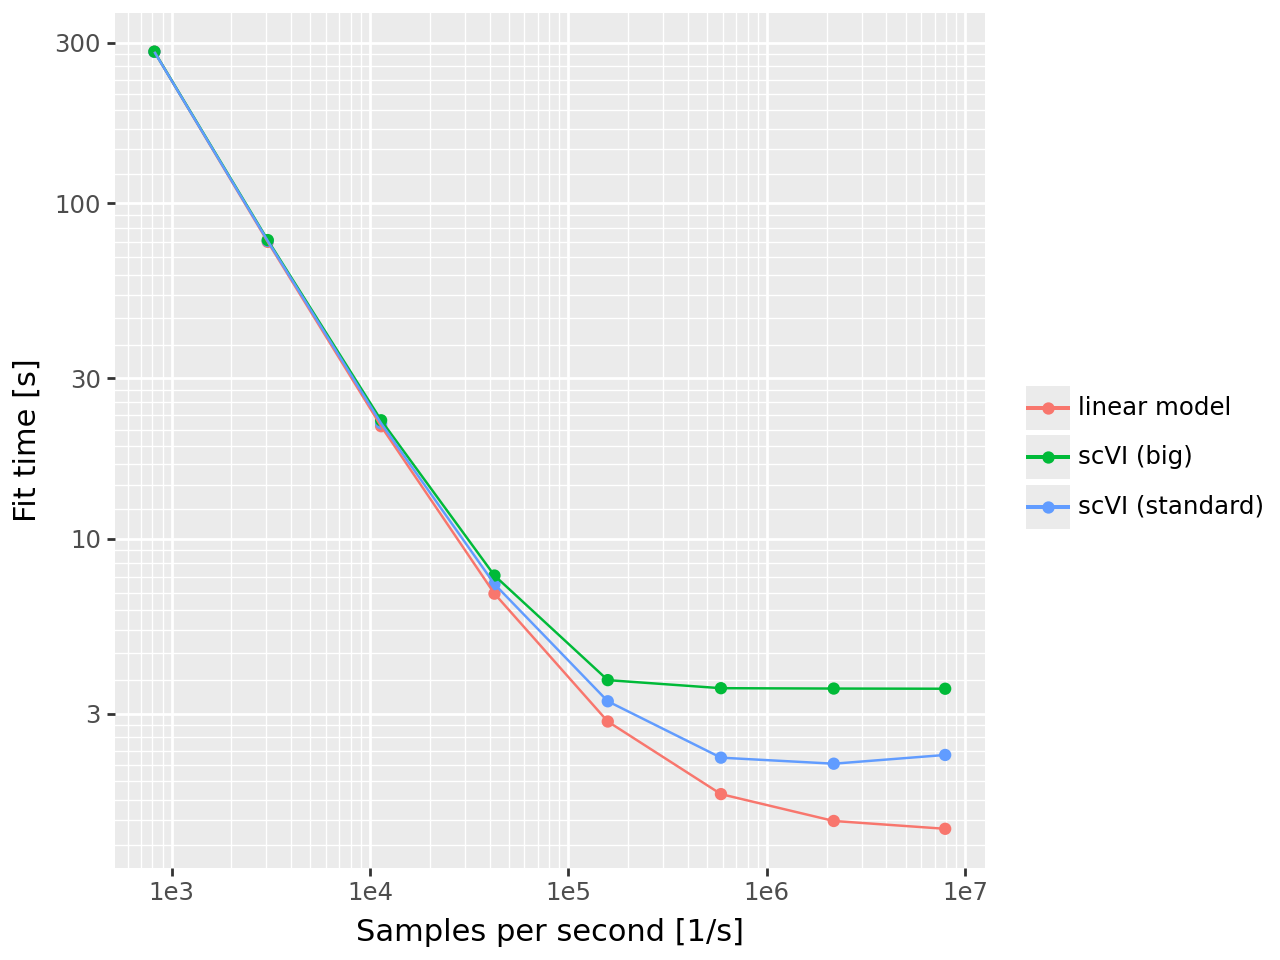

In [17]:
figure1 = (
    ggplot(fit_time_vs_loading_speed, aes(x="samples_per_sec", y="fit_time", color="model"))
    + geom_point()
    + geom_line()
    + scale_x_log10()
    + scale_y_log10()
    + xlab("Samples per second [1/s]")
    + ylab("Fit time [s]")
    + labs(color="")
    + theme(figure_size=(6.4, 4.8))
)

figure1.save("figures/figure1.svg")
figure1

## Figure 2

In [18]:
speed_comparision = (
    pd.read_parquet("source_data/speed_comp_aws.parquet")
    .query("loader != 'scDataset (annbatch matched settings)'")
    .assign(
        loader_color=lambda x: x.loader.str.split(" ").str[0],
        loader=lambda x: x.loader.str.replace(" ", "\n")
    )
)
speed_comparision

speed_comp_plot = (
    ggplot(speed_comparision, aes(x="loader", y="samples/sec", fill="loader_color"))
    + geom_col(show_legend=False)
    + xlab("")
    + ylab("Samples per second [1/s]")
    + scale_x_discrete(limits=[
        'annbatch\n(chunk_size=64)',
        'annbatch\n(chunk_size=128)',
        'annbatch\n(chunk_size=256)',
        'annbatch\n(chunk_size=512)',
        'MappedCollection',
        'scDataset\n(recommended\nsettings)'
    ])
    + theme(axis_text_x=element_text(rotation=90, hjust=1))
    + labs(tag="a")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [19]:
speed_comparision

,loader,samples/sec,loader_color
0,annbatch\n(chunk_size=64),22970.167873,annbatch
1,annbatch\n(chunk_size=128),26921.016445,annbatch
2,annbatch\n(chunk_size=256),29921.343282,annbatch
3,annbatch\n(chunk_size=512),32149.175057,annbatch
4,MappedCollection,1085.468714,MappedCollection
5,scDataset\n(recommended\nsettings),2112.048406,scDataset


In [5]:
time_per_epoch = pd.read_csv(
    "source_data/loading_times_full_epoch_fixed.csv"
).assign(
    total_time=lambda df: df.total_time / (60. * 60.),
    loader_color=lambda df: df.loader.str.split(" ").str[0],
    loader=lambda df: df.loader.str.replace(r'AnnBatch', 'annbatch', regex=True)
)
time_per_epoch_plot = (
    ggplot(time_per_epoch, aes(x="loader", y="total_time", fill="loader_color"))
    + geom_col(show_legend=False)
    + geom_text(aes(label="total_time"), va="bottom", format_string="{:.2f}")
    + xlab("")
    + ylab("Time per epoch [h]")
    + scale_x_discrete(limits=[
        'annbatch',
        'annbatch GPU',
        'MappedCollection',
        'scDataset'
    ])
    + ylim(0., 24.)
    + labs(tag="b")
    + theme(axis_text_x=element_text(rotation=90, hjust=1))
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [6]:
store_creation_time = pd.read_csv("source_data/store_creation_time.csv")
store_creation_time

,format,store_creation_time
0,zarr,6.724527
1,h5ad,15.242787


In [7]:
store_creation_time_plot = (
    ggplot(store_creation_time, aes(x="format", y="store_creation_time", fill="format"))
    + geom_col(show_legend=False)
    + xlab("")
    + ylab("Store creation time [h]")
    + labs(tag="c")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [8]:
chunked_loading_times = speed_comparision = (
    pd.read_parquet("source_data/speed_comp_aws.parquet")
    .query("loader in ['scDataset (annbatch matched settings)', 'annbatch (chunk_size=256)']")
    .assign(
        loader=lambda x: x.loader.replace({
            "scDataset (annbatch matched settings)": "h5ad (scDataset)",
            "annbatch (chunk_size=256)": "zarr (annbatch)"   
        })
    )
)
chunked_loading_times

,loader,samples/sec
2,zarr (annbatch),29921.343282
6,h5ad (scDataset),23048.011507


In [9]:
chunked_loading_times_plot = (
    ggplot(chunked_loading_times, aes(x="loader", y="samples/sec", fill="loader"))
    + geom_col(show_legend=False)
    + xlab("")
    + ylab("Samples per second [1/s]")
    + labs(tag="d")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [10]:
disk_usage = pd.DataFrame({
    "format": ["zarr", "h5ad"],
    "Disk usage [GB]": [325., 317.] 
})

disk_usage_plot = (
    ggplot(disk_usage, aes(x="format", y="Disk usage [GB]", fill="format"))
    + geom_col(show_legend=False)
    + ylim(0, 340)
    + xlab("")
    + labs(tag="e")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [11]:
batch_size_vs_fit_time = pd.read_csv("source_data/fit_time_vs_batch_size.csv", index_col=0)
batch_size_vs_fit_time

,batch_size,fit_time
0,256,263.117010
1,512,132.434669
2,1024,66.791550
3,2048,34.055916
4,4096,17.596677
5,8192,9.237130
6,16384,5.150969
7,32768,3.234217
8,65536,2.540616


In [12]:
batch_size_vs_fit_time_plot = (
    ggplot(batch_size_vs_fit_time, aes(x="batch_size", y="fit_time"))
    + geom_point()
    + geom_line()
    + scale_x_log10()
    + scale_y_log10()
    + xlab("Batch size")
    + ylab("Fit time [s]")
    + labs(color="")
    + labs(tag="f")
    + theme(plot_tag=element_text(fontweight='bold'))
)

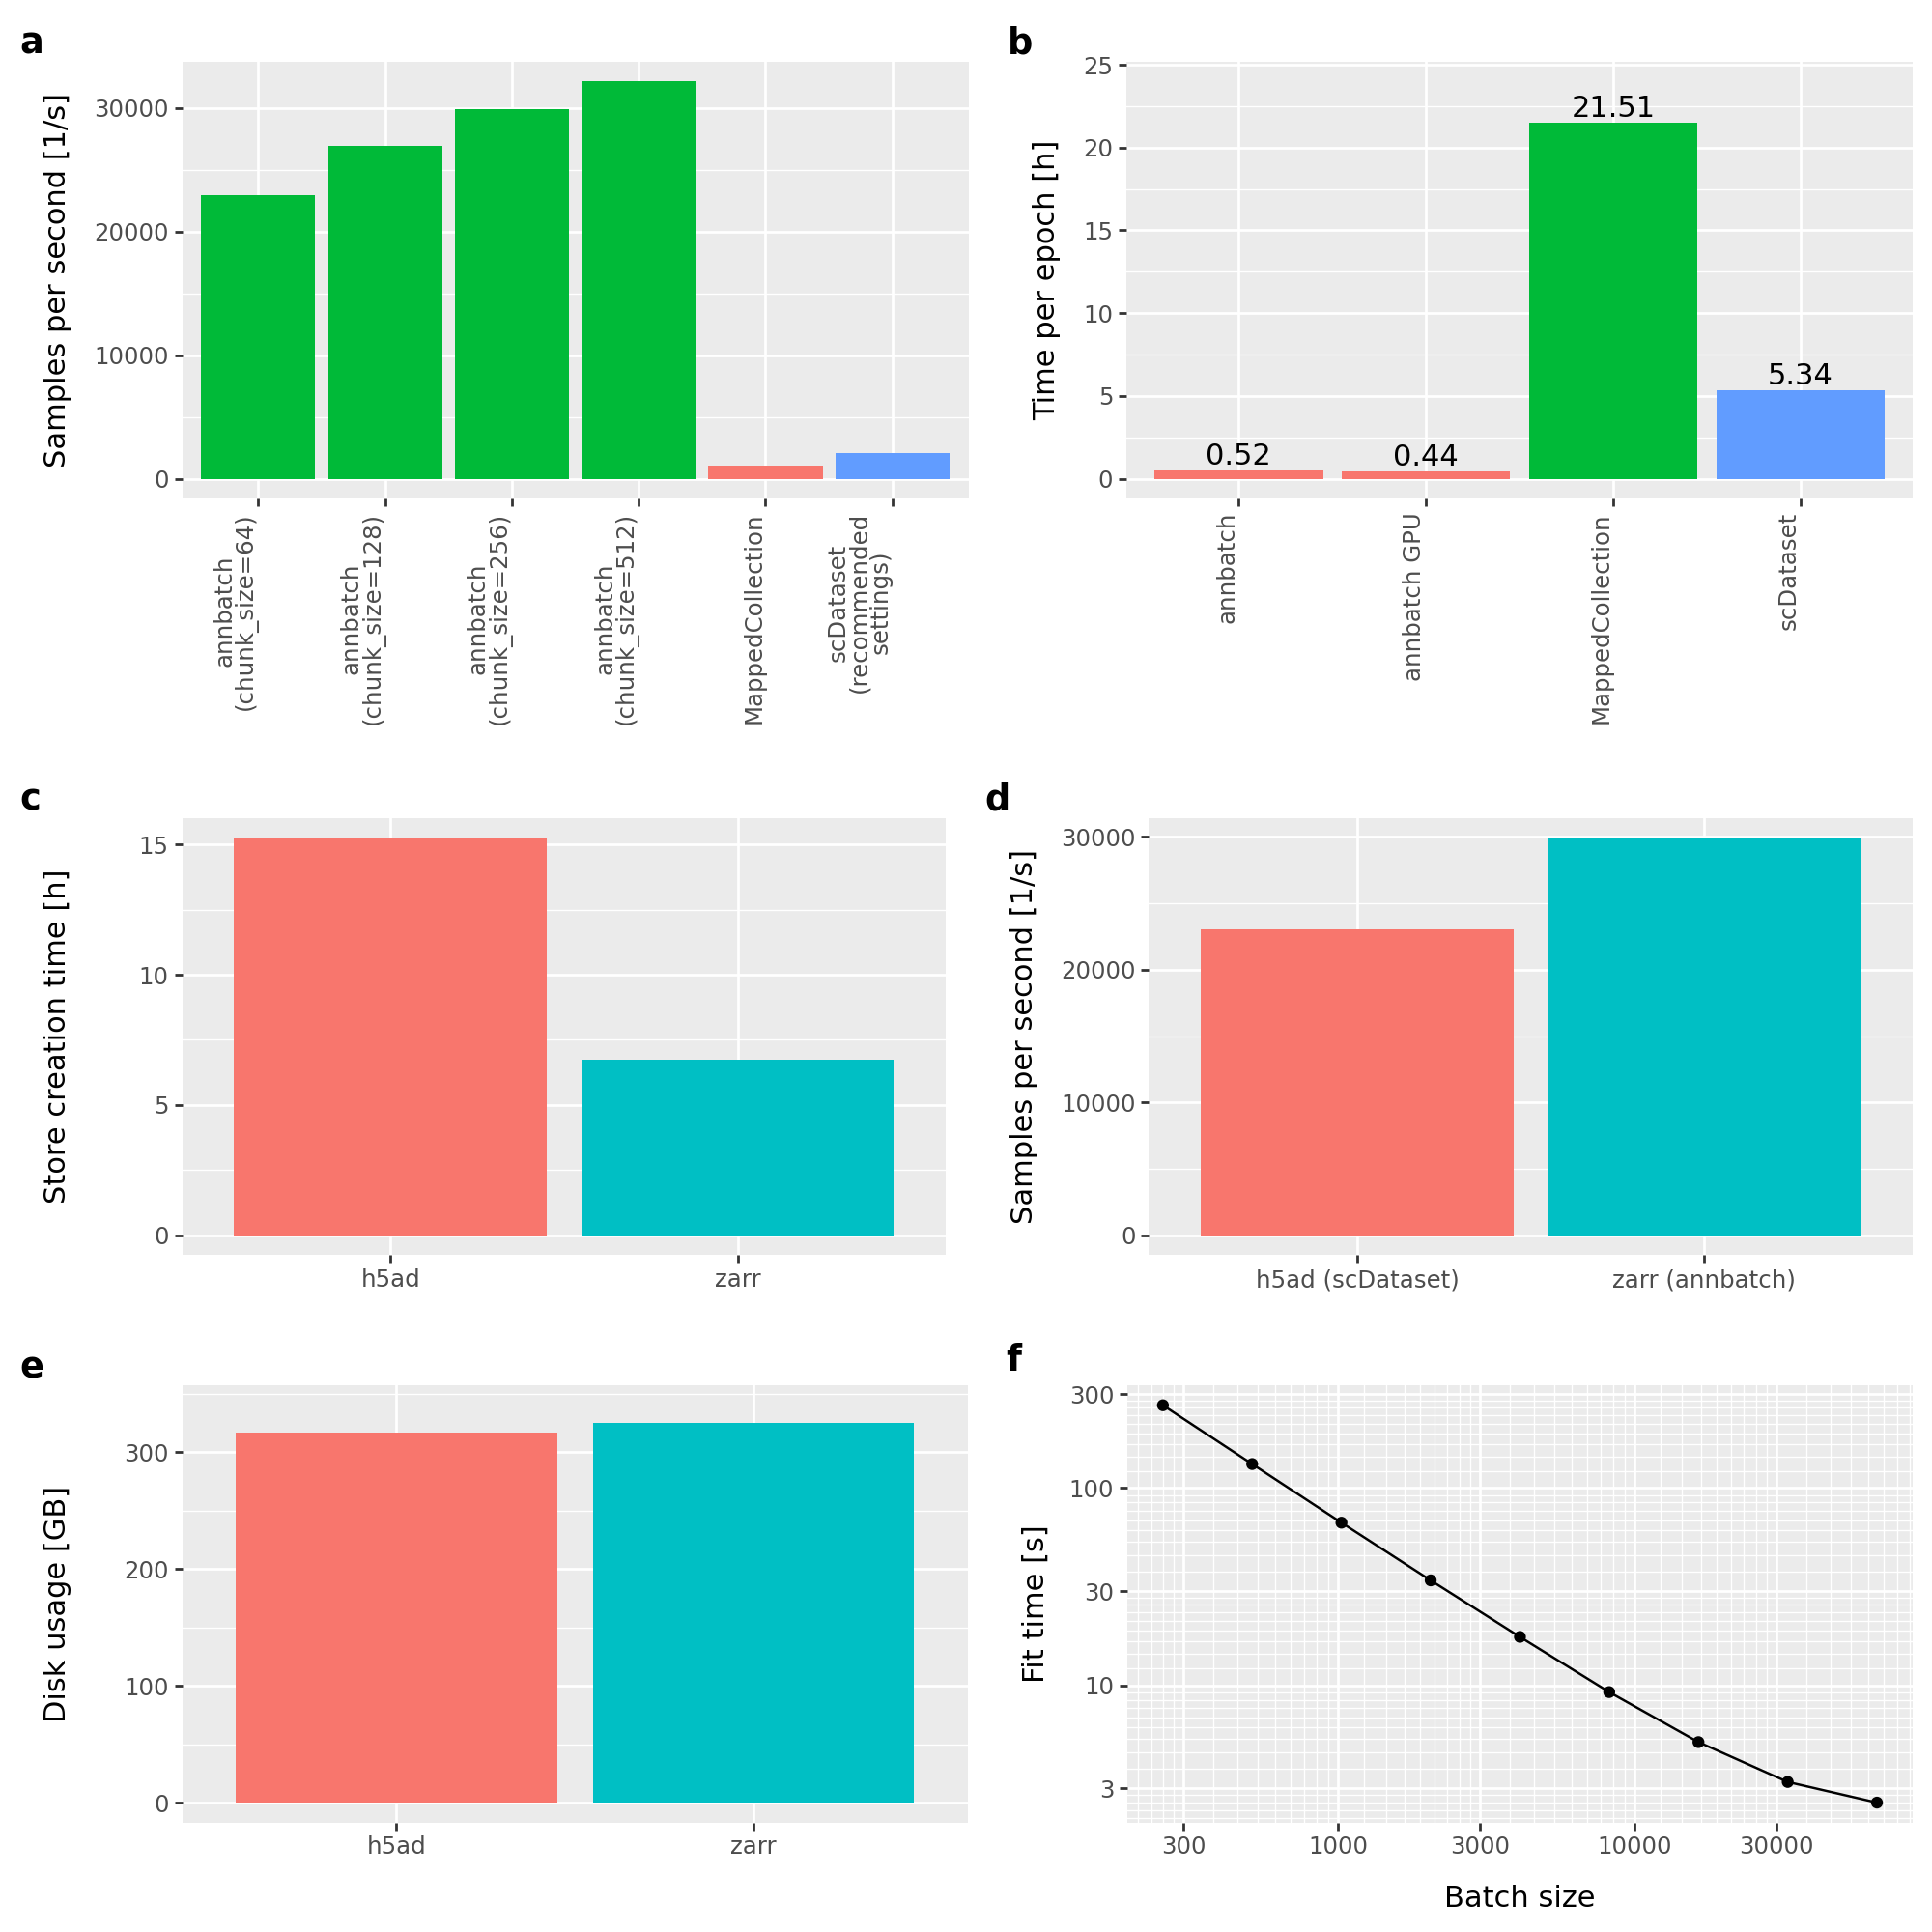

In [13]:
figure2 = (
    (speed_comp_plot | time_per_epoch_plot) /
    (store_creation_time_plot | chunked_loading_times_plot) /
    (disk_usage_plot | batch_size_vs_fit_time_plot)
) + theme(figure_size=(10, 10))
figure2

In [14]:
figure2.save("figures/figure2.svg")